# V3 empirical study — 1.5-year monthly calibration — return-based models

**This notebook is the computational source of truth.** The PDF in this folder is written from the same `payload` dict, so every table number matches.

| Item | Setting |
|------|---------|
| Models | GBM, Modified GBM, GARCH, Merton, GARCH–Merton |
| Companies | SPY (primary), AAPL, MSFT, AMZN |
| Regimes | Crisis 2008-08-01→2009-07-31 · Normal 2014-01-01→2014-12-31 · Late-cycle 2018-10-01→2019-09-30 · COVID 2019-09-01→2020-08-31 |
| Calibration | **1.5-year** lookback, **monthly** recalibration |
| Primary metric | Percentage RMSE |
| Secondary | MAE, Bias $ (model − market), Bias%, Early-exercise fraction |
| Paths | LSM American calls, `n_paths=10000`, `seed=42` |
| Code | V3 notebooks + `option_filters.py` + Euler-corrected Heston step |

In every table the **BEST** model is the lowest RMSE%. That row is **bold and green**.


## 0. Methodology and conditions

### No look-ahead
At monthly update t, parameters use only returns and listed quotes with `trading_date ≤ t`. LSM prices a Monday contract with the latest calibration row dated on or before that Monday. Option quotes are as-of the grid timestamp (same session, else the prior session).

### Shared sample (no model-specific data selection)
For each company × regime the Monday nearest-ATM listed-call sample is drawn **once** and passed to all five models in this report. Filters, testing dates, simulation settings, and the market benchmark are therefore identical.

### Filters (applied in this order)
1. Calls only; finite S, K, C.
2. No-arbitrage: C ≥ max(0, S−K).
3. Maturity: 7 ≤ DTE ≤ 60.
4. Moneyness: |S/K − 1| ≤ 10%.
5. Liquidity: premium ≥ 0.05; valid bid–ask and relative spread ≤ 50% when those columns exist; volume ≥ 1 when present.

### Metrics
- Primary: RMSE%.
- Secondary: MAE (dollars), Bias $ = mean(model − market), **Bias% = 100 × mean((model − market)/market)**, early-exercise fraction.
- Ranking uses RMSE% only. The dollar bias column is kept; Bias% is the scale-free companion.

### Model-correctness adjustments
- Heston / Heston–Merton: option-implied Fourier NLS for (κ, θ, ξ, ρ, v0). Not Method A.
- Euler: stock return over [t, t+Δt] uses **current** v_t; then update v_{t+Δt}.
- LSM never averages paths before stopping.

### Data limits
Equity adj-close starts **2003-12-01**. Listed-option panels start **2008-01**. Estimators use all available history when the requested lookback is longer than the file.

### Re-run
This notebook is a grouped companion. It loads stored cells and does **not** re-run LSM. To rebuild only this group's PDF/notebook, call `groups.write_group(...)`. Do not set RECOMPUTE on the six-model engine; that would overwrite the original study files.


In [1]:
import sys
from pathlib import Path
from IPython.display import display, HTML, Markdown, Image
ROOT = Path.cwd()
for cand in [ROOT, *ROOT.parents]:
    scripts = cand / 'V3-Models_result' / 'scripts'
    if scripts.exists():
        sys.path.insert(0, str(scripts))
        break
import run_v3_1p5y_10k_monthly_empirical_study_groups as groups
payload = groups.load_group('return_based')
print('cells', len(payload['cells']), 'models', payload['meta']['models'])
# Rebuild this group's PDF/notebook only (does not overwrite the six-model study):
# groups.write_group('return_based')

## 1. Shared evaluation sample


In [1]:
from IPython.display import HTML, display
rows = ['<h4>n contracts (identical across models)</h4>']
display(HTML(''.join(study._html_table(payload['tables'][k]) if False else '')))
meta = payload['shared_contracts']
import pandas as pd
df = pd.DataFrame([{ 'regime': r, **meta[r]['n'], 'start': meta[r]['period_start'], 'end': meta[r]['period_end']} for r in study.REGIME_ORDER])
display(df)

Regime,Window,SPY,AAPL,MSFT,AMZN
2008-2009 Crisis,2008-08-01 → 2009-07-31,50,50,50,50
2013-2014 Normal,2014-01-01 → 2014-12-31,50,50,50,50
2018-2019 Late-cycle,2018-10-01 → 2019-09-30,50,51,50,51
2019-2020 COVID,2019-09-01 → 2020-08-31,50,50,50,50


## 2.1 Detailed tables — `SPY`


### Table SPY-1. SPY · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · n = 50 contracts · **BEST = Modified GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['SPY|2008-2009'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,55.01,1.4054,+0.2705,+21.16,24.5%,5
Modified GBM,47.67,1.2488,-0.0854,+10.62,25.9%,1
GARCH,52.86,1.6883,+1.6456,+43.57,20.8%,2
Merton,52.87,1.3685,+0.1826,+18.56,20.3%,3
GARCH–Merton,54.76,1.7780,+1.7384,+46.28,20.5%,4


### Table SPY-2. SPY · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · n = 50 contracts · **BEST = Modified GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['SPY|2013-2014'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,38.08,0.6850,+0.4678,+24.88,26.1%,3
Modified GBM,37.08,0.6750,+0.4371,+23.66,26.6%,1
GARCH,38.24,0.6860,+0.4700,+24.96,23.3%,4
Merton,37.52,0.6728,+0.4520,+24.20,24.7%,2
GARCH–Merton,42.83,0.7744,+0.6153,+30.82,22.5%,5


### Table SPY-3. SPY · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · n = 50 contracts · **BEST = Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['SPY|2018-2019'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,49.51,1.6628,+1.1528,+32.90,21.8%,2
Modified GBM,51.83,1.7487,+1.2257,+34.67,22.2%,3
GARCH,71.72,2.1416,+1.7421,+45.61,21.9%,4
Merton,47.62,1.5845,+1.0524,+30.44,16.2%,1
GARCH–Merton,77.02,2.4122,+2.1360,+54.80,20.5%,5


### Table SPY-4. SPY · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · n = 50 contracts · **BEST = GARCH** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['SPY|2019-2020'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,64.88,3.6003,+1.6141,+44.13,23.9%,4
Modified GBM,64.56,3.4810,+1.5419,+44.09,24.2%,3
GARCH,56.59,2.9250,+2.0268,+34.97,32.7%,1
Merton,60.38,3.3441,+1.2734,+38.99,18.7%,2
GARCH–Merton,66.14,3.4255,+2.8053,+46.06,31.4%,5


## 2.2 Detailed tables — Company summary


Same four-regime layout as SPY. Each value is the arithmetic mean of **AAPL, MSFT, AMZN**. Ranking uses mean RMSE%.


### Table Co-1. Company summary · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · mean of AAPL, MSFT, AMZN · n̄ = 50 · **BEST = Modified GBM** (lowest mean RMSE%).


In [1]:
display(HTML(study._html_table(study._average_company_table(payload, '2008-2009', study._equity_tickers()))))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,49.54,1.4392,+0.7383,+23.71,23.1%,3
Modified GBM,44.73,1.2794,+0.4468,+17.76,24.6%,1
GARCH,52.30,1.5524,+1.3564,+39.86,21.3%,4
Merton,48.36,1.4136,+0.6645,+21.87,19.1%,2
GARCH–Merton,62.67,1.8758,+1.7623,+51.27,20.1%,5


### Table Co-2. Company summary · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · mean of AAPL, MSFT, AMZN · n̄ = 50 · **BEST = Merton** (lowest mean RMSE%).


In [1]:
display(HTML(study._html_table(study._average_company_table(payload, '2013-2014', study._equity_tickers()))))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,47.93,2.2358,+1.7353,+36.05,24.6%,3
Modified GBM,44.77,2.0621,+1.5246,+33.19,25.4%,2
GARCH,58.97,2.3886,+2.0506,+45.16,22.8%,4
Merton,42.53,2.0512,+1.4116,+30.28,18.4%,1
GARCH–Merton,79.38,3.5675,+3.5143,+67.98,18.9%,5


### Table Co-3. Company summary · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · mean of AAPL, MSFT, AMZN · n̄ = 51 · **BEST = Merton** (lowest mean RMSE%).


In [1]:
display(HTML(study._html_table(study._average_company_table(payload, '2018-2019', study._equity_tickers()))))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,39.31,8.0415,+4.4076,+23.84,23.2%,3
Modified GBM,38.45,8.4064,+5.2944,+22.84,24.1%,2
GARCH,43.38,7.7461,+5.7535,+28.81,19.5%,4
Merton,37.91,8.0116,+3.8942,+21.67,19.3%,1
GARCH–Merton,52.78,9.0776,+7.7086,+39.80,17.7%,5


### Table Co-4. Company summary · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · mean of AAPL, MSFT, AMZN · n̄ = 50 · **BEST = Merton** (lowest mean RMSE%).


In [1]:
display(HTML(study._html_table(study._average_company_table(payload, '2019-2020', study._equity_tickers()))))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,48.18,10.6159,+4.7227,+30.10,24.0%,3
Modified GBM,47.07,10.6143,+4.7108,+28.16,24.6%,2
GARCH,52.33,9.6856,+5.4722,+33.95,24.5%,4
Merton,46.08,10.3990,+4.1300,+27.28,19.4%,1
GARCH–Merton,153.02,12.2225,+9.1243,+58.27,23.5%,5


## 2.3 Detailed tables — `AAPL`


### Table AAPL-1. AAPL · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · n = 50 contracts · **BEST = GARCH** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AAPL|2008-2009'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,57.67,2.4326,+1.3849,+31.10,22.8%,4
Modified GBM,51.94,2.1591,+0.9309,+23.67,23.5%,2
GARCH,48.71,2.7044,+2.5500,+40.72,19.1%,1
Merton,55.67,2.3640,+1.2255,+28.42,18.3%,3
GARCH–Merton,58.94,3.2224,+3.1062,+50.39,15.9%,5


### Table AAPL-2. AAPL · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · n = 50 contracts · **BEST = GARCH** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AAPL|2013-2014'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,50.20,3.5766,+3.5387,+38.63,24.6%,4
Modified GBM,45.44,3.1559,+3.1131,+34.56,25.4%,2
GARCH,45.44,3.1849,+3.0454,+29.67,22.2%,1
Merton,45.50,3.2302,+3.1799,+33.94,19.5%,3
GARCH–Merton,65.87,4.9053,+4.9027,+53.60,17.8%,5


### Table AAPL-3. AAPL · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · n = 51 contracts · **BEST = Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AAPL|2018-2019'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,32.53,1.7033,+1.0081,+18.76,23.9%,2
Modified GBM,34.33,1.7907,+1.1260,+20.69,24.0%,3
GARCH,48.45,2.0164,+1.5757,+29.40,20.0%,4
Merton,30.59,1.5914,+0.8543,+16.31,19.9%,1
GARCH–Merton,59.31,2.6521,+2.3998,+42.76,18.5%,5


### Table AAPL-4. AAPL · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · n = 50 contracts · **BEST = Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AAPL|2019-2020'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,46.19,3.9995,+2.3663,+30.76,23.8%,3
Modified GBM,45.88,3.7712,+2.1029,+29.60,24.4%,2
GARCH,61.17,4.8546,+4.4651,+43.67,24.2%,4
Merton,43.61,3.6886,+1.9753,+27.36,18.9%,1
GARCH–Merton,71.81,5.9515,+5.7532,+57.54,24.2%,5


## 2.4 Detailed tables — `MSFT`


### Table MSFT-1. MSFT · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · n = 50 contracts · **BEST = Modified GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['MSFT|2008-2009'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,44.02,0.3723,+0.0897,+17.99,24.1%,3
Modified GBM,41.99,0.3590,+0.0799,+16.83,25.2%,1
GARCH,70.79,0.5879,+0.5440,+54.27,30.0%,4
Merton,42.94,0.3684,+0.0716,+16.18,19.7%,2
GARCH–Merton,81.24,0.6935,+0.6704,+66.90,29.6%,5


### Table MSFT-2. MSFT · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · n = 50 contracts · **BEST = Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['MSFT|2013-2014'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,62.49,0.4283,+0.4261,+52.98,24.7%,3
Modified GBM,59.39,0.4056,+0.4025,+50.16,25.7%,2
GARCH,90.24,0.6511,+0.6511,+78.36,25.2%,4
Merton,54.85,0.3679,+0.3602,+45.39,17.1%,1
GARCH–Merton,112.93,0.8656,+0.8656,+102.63,21.6%,5


### Table MSFT-3. MSFT · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · n = 50 contracts · **BEST = Modified GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['MSFT|2018-2019'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,41.73,1.0839,+0.8054,+27.55,23.0%,3
Modified GBM,33.44,0.8877,+0.4849,+17.78,25.3%,1
GARCH,42.43,1.0703,+0.9006,+30.13,18.9%,4
Merton,40.33,1.0504,+0.7474,+25.77,19.8%,2
GARCH–Merton,52.89,1.3664,+1.2944,+42.08,17.0%,5


### Table MSFT-4. MSFT · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · n = 50 contracts · **BEST = Modified GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['MSFT|2019-2020'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,45.93,2.0118,+1.0018,+28.12,24.5%,3
Modified GBM,40.97,1.7579,+0.6597,+22.12,25.1%,1
GARCH,60.29,2.3979,+1.9268,+35.85,29.6%,4
Merton,44.13,1.8737,+0.7910,+25.02,19.7%,2
GARCH–Merton,346.80,6.7038,+6.3160,+88.26,28.7%,5


## 2.5 Detailed tables — `AMZN`


### Table AMZN-1. AMZN · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · n = 50 contracts · **BEST = GARCH** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AMZN|2008-2009'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,46.92,1.5126,+0.7403,+22.05,22.4%,4
Modified GBM,40.25,1.3199,+0.3297,+12.79,24.9%,2
GARCH,37.41,1.3649,+0.9751,+24.58,14.6%,1
Merton,46.47,1.5086,+0.6964,+21.02,19.3%,3
GARCH–Merton,47.82,1.7115,+1.5102,+36.53,14.8%,5


### Table AMZN-2. AMZN · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · n = 50 contracts · **BEST = Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AMZN|2013-2014'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,31.09,2.7024,+1.2412,+16.54,24.6%,3
Modified GBM,29.48,2.6249,+1.0584,+14.84,25.1%,2
GARCH,41.25,3.3299,+2.4552,+27.44,21.0%,4
Merton,27.23,2.5555,+0.6946,+11.52,18.7%,1
GARCH–Merton,59.35,4.9315,+4.7746,+47.73,17.4%,5


### Table AMZN-3. AMZN · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · n = 51 contracts · **BEST = GARCH** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AMZN|2018-2019'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,43.66,21.3373,+11.4095,+25.21,22.9%,3
Modified GBM,47.59,22.5407,+14.2723,+30.06,23.0%,5
GARCH,39.26,20.1516,+14.7843,+26.92,19.6%,1
Merton,42.81,21.3929,+10.0809,+22.92,18.1%,2
GARCH–Merton,46.13,23.2142,+19.4315,+34.56,17.6%,4


### Table AMZN-4. AMZN · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · n = 50 contracts · **BEST = GARCH** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AMZN|2019-2020'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,52.42,25.8364,+10.7999,+31.41,23.8%,4
Modified GBM,54.35,26.3138,+11.3697,+32.76,24.2%,5
GARCH,35.53,21.8043,+10.0246,+22.34,19.6%,1
Merton,50.50,25.6348,+9.6238,+29.46,19.7%,3
GARCH–Merton,40.45,24.0122,+15.3037,+29.03,17.5%,2


## 3. Summary tables


### Table S1 — Overall ranking


In [1]:
display(HTML('overall ranking table is rendered from payload["summary_overall"]'))

Rank,Model,Mean RMSE%,Median RMSE%,# cells best
1,Merton BEST,45.19,44.82,5
2,Modified GBM,45.39,45.66,5
3,GBM,47.65,46.56,0
4,GARCH,52.52,48.58,6
5,GARCH–Merton,80.27,59.33,0


## 4. Figures


### Figure 1 — RMSE% by regime (mean of four companies)


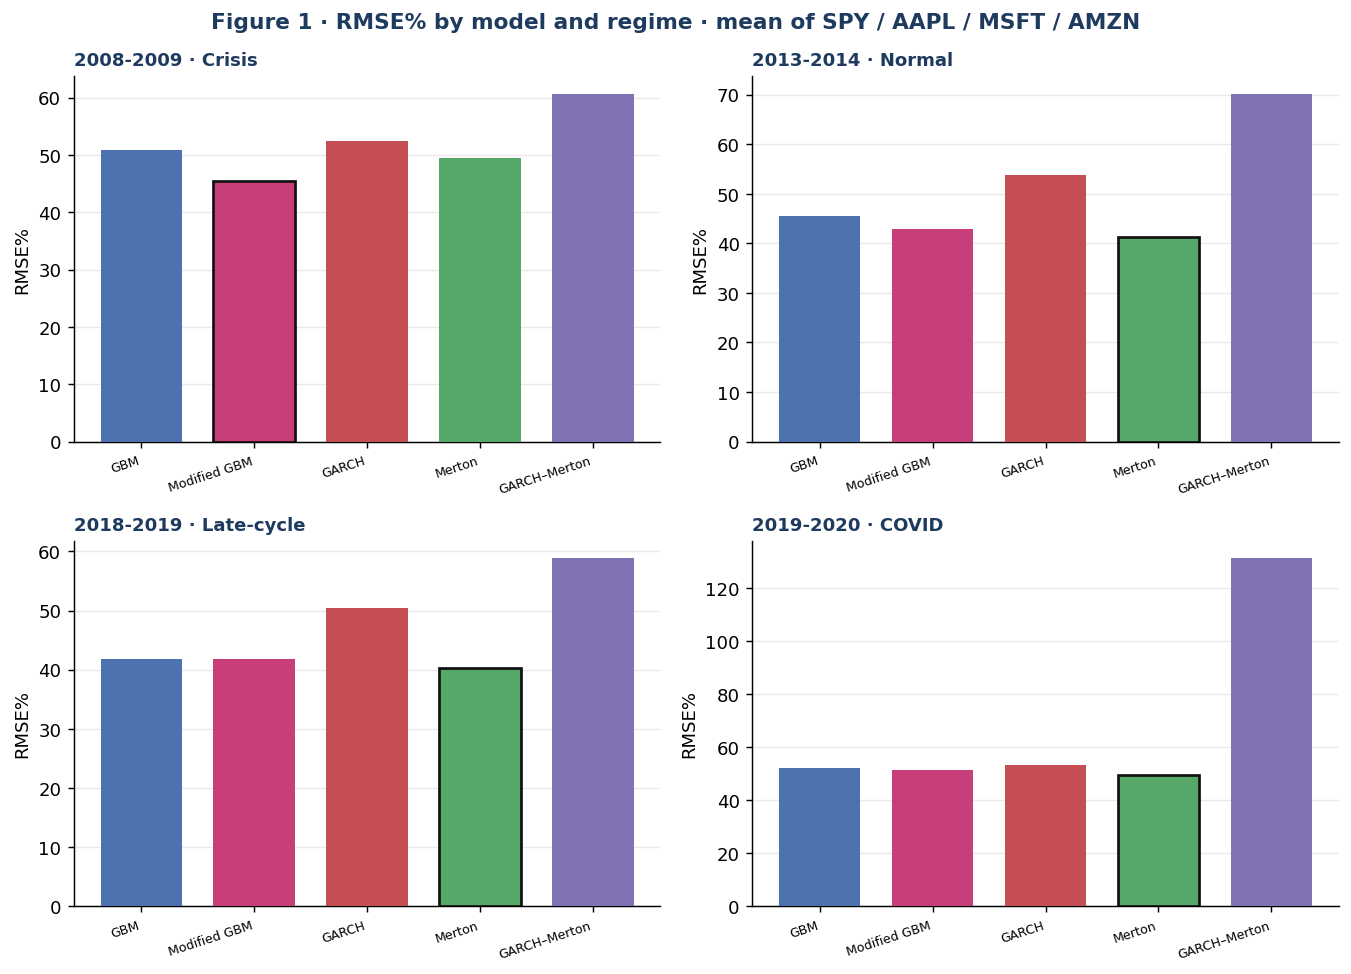

In [1]:
pass  # figure embedded from the same payload used for the PDF

### Figure 2 — RMSE% by company


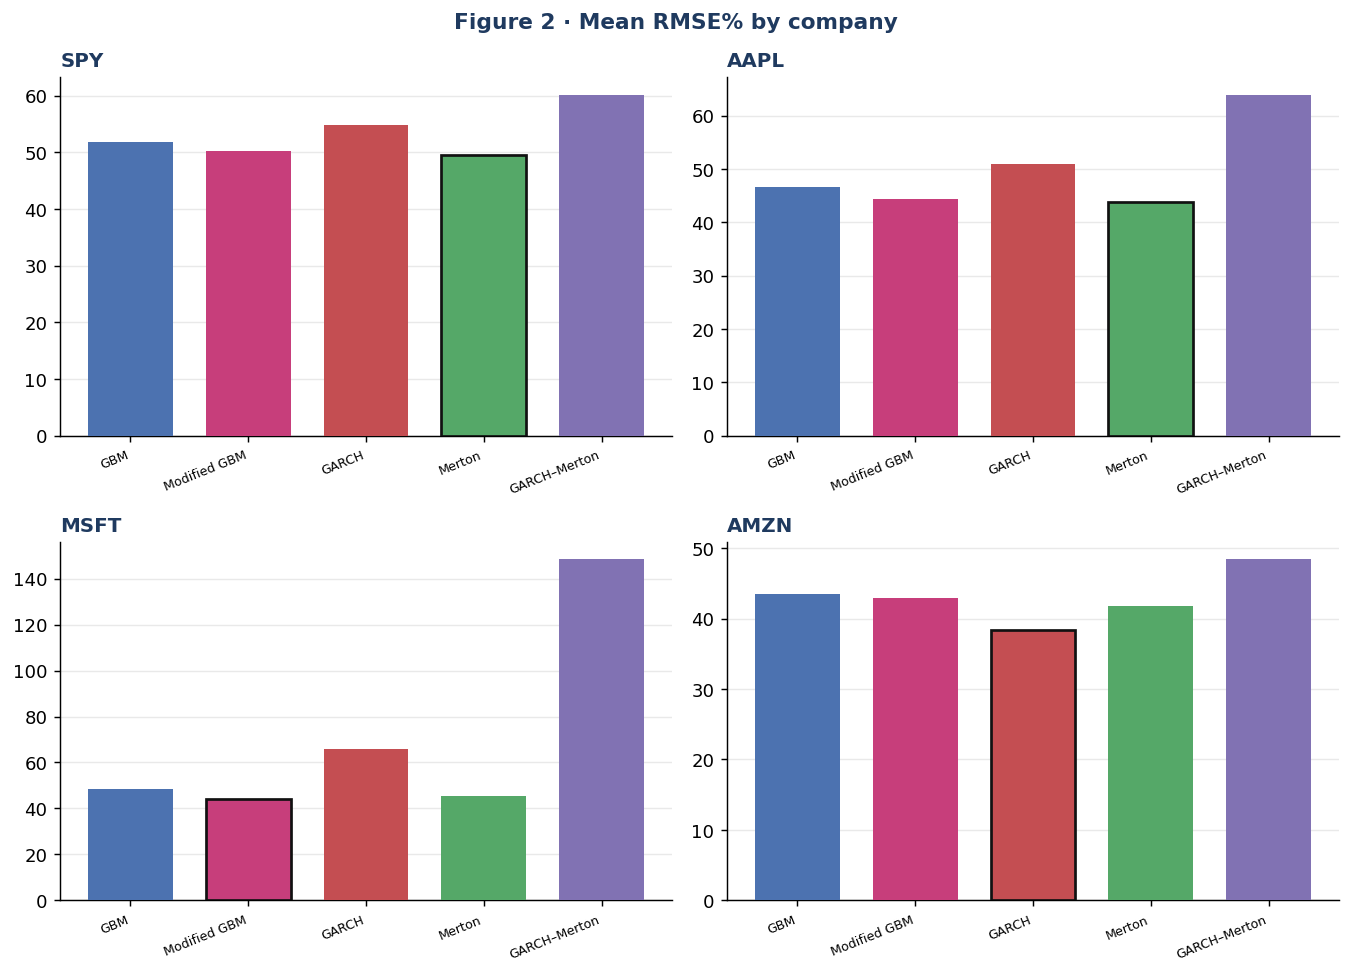

In [1]:
pass

### Figure 3 — Rank heatmap


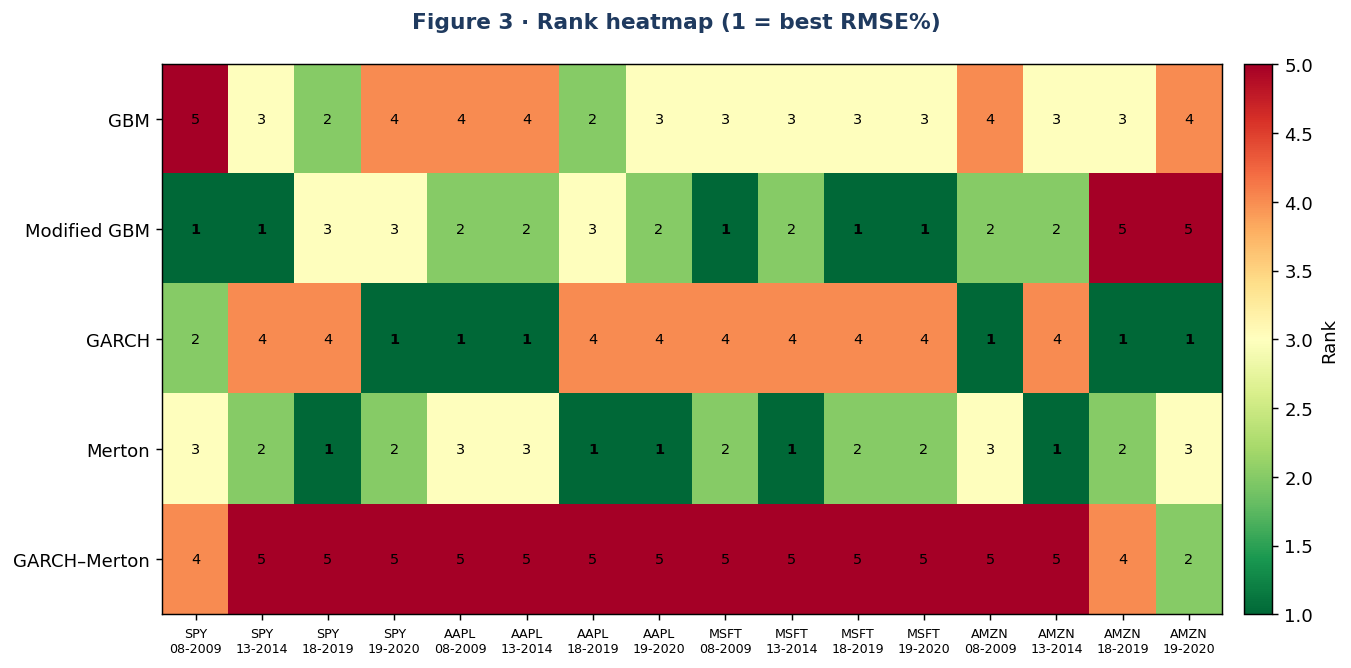

In [1]:
pass

## 5. Final analysis

- On mean percentage RMSE across the 16 company×regime cells, Merton is the best overall model (mean RMSE% = 45.19; 5 of 16 cells).

- Second overall is Modified GBM (mean RMSE% = 45.39; 5 cells).

- The ranking is not stable. Best-in-cell models across the 16 tables: GARCH, Merton, Modified GBM.

- SPY: lowest mean RMSE% is Merton (49.60); wins 1 of 4 regimes.

- AAPL: lowest mean RMSE% is Merton (43.84); wins 2 of 4 regimes.

- MSFT: lowest mean RMSE% is Modified GBM (43.95); wins 3 of 4 regimes.

- AMZN: lowest mean RMSE% is GARCH (38.36); wins 3 of 4 regimes.

- 2008-2009 (Crisis): best mean RMSE% is Modified GBM (45.46).

- 2013-2014 (Normal): best mean RMSE% is Merton (41.28).

- 2018-2019 (Late-cycle): best mean RMSE% is Merton (40.34).

- 2019-2020 (COVID): best mean RMSE% is Merton (49.66).

- No-jump models as a group have lower mean RMSE% (48.52) than the jump models in this report (62.73).

- For the overall winner (Merton), crisis RMSE% is 49.49 vs 41.28 in the 2014 normal year — absolute pricing error is regime-dependent even when the ranking is not.

- These conclusions are conditional on the V3 filters, 1.5-year monthly calibration, Monday ATM sample, LSM with 10,000 paths, and American-call quotes only. They are not a statement about European options or other tenors.


## 6. Reproducibility

This grouped report is assembled from the frozen 10,000-path cells. No new calibration or LSM.

```python
import run_v3_1p5y_10k_monthly_empirical_study_groups as groups
payload = groups.load_group('return_based')
groups.write_group('return_based')
```

The original six-model files `V3_1p5y_monthly_empirical_study.pdf` / `.ipynb` are not rewritten.
Partial results remain in `V3-Models_result/results/empirical_study_1p5y_monthly_10000/partial/`.
Shared contracts are frozen in `shared_contracts.json`.
